In [1]:
import os
os.listdir('data/wesad_raw')

['WESAD']

In [2]:
os.listdir('data/wesad_raw/WESAD')

['S3',
 'S15',
 'S11',
 'S7',
 'S6',
 'S10',
 'S17',
 'S9',
 'S14',
 'S2',
 'S13',
 'wesad_readme.pdf',
 'S16',
 'S5',
 'S4',
 'S8']

In [3]:
import pickle

with open('data/wesad_raw/WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(type(data))
print(data.keys())


<class 'dict'>
dict_keys(['signal', 'label', 'subject'])


In [4]:
print(type(data))
print(data.keys())
print(data['signal'].keys())
print(data['signal']['wrist'].keys())


<class 'dict'>
dict_keys(['signal', 'label', 'subject'])
dict_keys(['chest', 'wrist'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [5]:
bvp = data['signal']['wrist']['BVP']
labels = data['label']

print("BVP signal shape:", bvp.shape)
print("Labels shape:", labels.shape)

BVP signal shape: (389056, 1)
Labels shape: (4255300,)


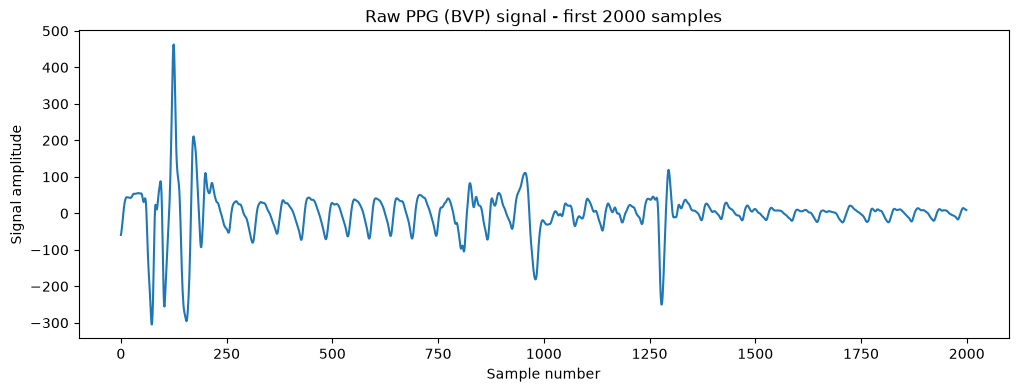

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(bvp[:2000])
plt.title("Raw PPG (BVP) signal - first 2000 samples")
plt.xlabel("Sample number")
plt.ylabel("Signal amplitude")
plt.show()


In [7]:
import neurokit2 as nk
import numpy as np
import pandas as pd

def extract_features_for_subject(subject_id, base_path='data/wesad_raw/WESAD'):
    with open(f'{base_path}/{subject_id}/{subject_id}.pkl', 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    bvp = data['signal']['wrist']['BVP'].flatten()
    labels = data['label']  # this is sampled at 700Hz (chest device rate)

    fs_bvp = 64        # BVP sampling rate
    fs_label = 700      # label sampling rate

    window_sec = 60
    step_sec = 30
    window_size = window_sec * fs_bvp
    step_size = step_sec * fs_bvp

    rows = []
    for start in range(0, len(bvp) - window_size, step_size):
        end = start + window_size
        segment = bvp[start:end]

        # figure out the matching label for this time window
        label_start = int(start / fs_bvp * fs_label)
        label_end = int(end / fs_bvp * fs_label)
        window_labels = labels[label_start:label_end]
        if len(window_labels) == 0:
            continue
        majority_label = np.bincount(window_labels.astype(int)).argmax()

        # only keep baseline(1), stress(2), amusement(3) — skip transitions/other
        if majority_label not in [1, 2, 3]:
            continue

        try:
            signals, info = nk.ppg_process(segment, sampling_rate=fs_bvp)
            hrv = nk.hrv(info, sampling_rate=fs_bvp, show=False)
            hrv['subject'] = subject_id
            hrv['label'] = majority_label
            rows.append(hrv)
        except Exception as e:
            continue

    if len(rows) == 0:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)

In [8]:
subjects = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']

all_data = []
for subj in subjects:
    print("Processing", subj)
    df = extract_features_for_subject(subj)
    all_data.append(df)

full_dataset = pd.concat(all_data, ignore_index=True)
print(full_dataset.shape)
full_dataset.head()

Processing S2


/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-te

Processing S3


/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-te

Processing S4


...

Processing S17


/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-te

(1105, 97)


/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/achuthan/ble-vitals-platform/venv_ml/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,label,HRV_DFA_alpha2,HRV_MFDFA_alpha2_Width,HRV_MFDFA_alpha2_Peak,HRV_MFDFA_alpha2_Mean,HRV_MFDFA_alpha2_Max,HRV_MFDFA_alpha2_Delta,HRV_MFDFA_alpha2_Asymmetry,HRV_MFDFA_alpha2_Fluctuation,HRV_MFDFA_alpha2_Increment
0,779.166667,275.781260,NaN,NaN,NaN,NaN,NaN,NaN,375.408878,377.906313,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,805.864726,262.089908,NaN,NaN,NaN,NaN,NaN,NaN,345.854511,348.264038,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,802.011986,240.220151,NaN,NaN,NaN,NaN,NaN,NaN,320.714517,322.950681,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,785.625000,233.239932,NaN,NaN,NaN,NaN,NaN,NaN,284.411195,286.341227,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,787.708333,203.807542,NaN,NaN,NaN,NaN,NaN,NaN,232.885186,234.472455,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
full_dataset.to_csv('data/wesad_features.csv', index=False)

In [12]:
import numpy as np

full_dataset = pd.read_csv('data/wesad_features.csv')

# Replace infinite values with NaN so they get caught by dropna
full_dataset = full_dataset.replace([np.inf, -np.inf], np.nan)

# Drop columns that are mostly empty
full_dataset = full_dataset.dropna(axis=1, thresh=int(0.9*len(full_dataset)))

# Drop any remaining rows with missing/bad values
full_dataset = full_dataset.dropna(axis=0)

print(full_dataset.shape)

(1085, 80)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

feature_cols = [c for c in full_dataset.columns if c not in ['subject', 'label']]

results = []
for test_subj in full_dataset['subject'].unique():
    train_df = full_dataset[full_dataset['subject'] != test_subj]
    test_df  = full_dataset[full_dataset['subject'] == test_subj]

    X_train, y_train = train_df[feature_cols], train_df['label']
    X_test, y_test   = test_df[feature_cols], test_df['label']

    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    results.append({'subject': test_subj, 'accuracy': acc, 'f1': f1})
    print(f"{test_subj}: acc={acc:.2f}, f1={f1:.2f}")

results_df = pd.DataFrame(results)
print("\nAverage accuracy:", results_df['accuracy'].mean())
print("Average F1:", results_df['f1'].mean())

S2: acc=0.71, f1=0.52
S3: acc=0.67, f1=0.48
S4: acc=0.83, f1=0.61
S5: acc=0.71, f1=0.53
S6: acc=0.72, f1=0.53
S7: acc=0.76, f1=0.59
S8: acc=0.82, f1=0.61
S9: acc=0.67, f1=0.47
S10: acc=0.45, f1=0.32
S11: acc=0.73, f1=0.55
S13: acc=0.73, f1=0.56
S14: acc=0.85, f1=0.76
S15: acc=0.49, f1=0.40
S16: acc=0.83, f1=0.65
S17: acc=0.83, f1=0.61

Average accuracy: 0.7211236339129787
Average F1: 0.5451023730920196


In [14]:
import joblib

final_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_model.fit(full_dataset[feature_cols], full_dataset['label'])

joblib.dump(final_model, 'models/vitals_anomaly_detector.pkl')

['models/vitals_anomaly_detector.pkl']

In [16]:
results_df

,subject,accuracy,f1
0,S2,0.710145,0.519976
1,S3,0.671429,0.483483
2,S4,0.826087,0.612665
3,S5,0.708333,0.526774
4,S6,0.722222,0.525569
5,S7,0.763889,0.586330
6,S8,0.819444,0.610226
7,S9,0.666667,0.467387
8,S10,0.453333,0.319816
9,S11,0.733333,0.548126


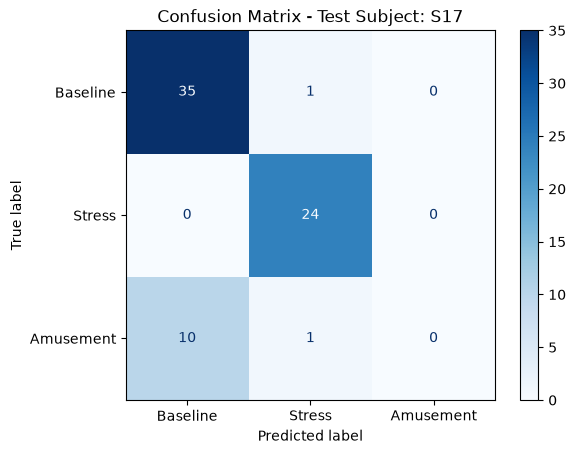

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use predictions from your LAST loop iteration, or rerun on one subject as example
cm = confusion_matrix(y_test, preds, labels=[1,2,3])
disp = ConfusionMatrixDisplay(cm, display_labels=['Baseline','Stress','Amusement'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - Test Subject: {test_subj}")
plt.show()

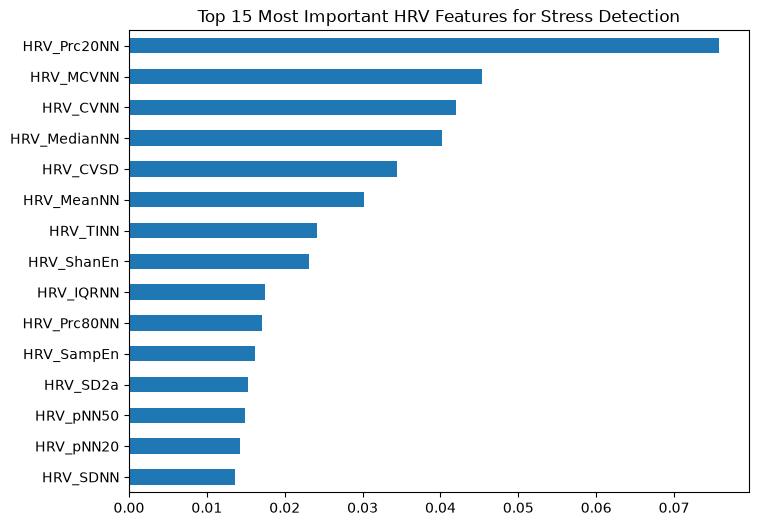

In [18]:
importances = pd.Series(final_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.title("Top 15 Most Important HRV Features for Stress Detection")
plt.gca().invert_yaxis()
plt.show()

In [19]:
plt.savefig('models/feature_importance.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [20]:
# Merge label 3 (amusement) into label 1 (baseline) -> both become "non-stress"
full_dataset['binary_label'] = full_dataset['label'].apply(lambda x: 1 if x == 2 else 0)
# 1 = Stress, 0 = Non-stress

results_binary = []
for test_subj in full_dataset['subject'].unique():
    train_df = full_dataset[full_dataset['subject'] != test_subj]
    test_df  = full_dataset[full_dataset['subject'] == test_subj]

    X_train, y_train = train_df[feature_cols], train_df['binary_label']
    X_test, y_test   = test_df[feature_cols], test_df['binary_label']

    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    results_binary.append({'subject': test_subj, 'accuracy': acc, 'f1': f1})

results_binary_df = pd.DataFrame(results_binary)
print("Average binary accuracy:", results_binary_df['accuracy'].mean())
print("Average binary F1:", results_binary_df['f1'].mean())
results_binary_df

Average binary accuracy: 0.8751897698590899
Average binary F1: 0.8484180559548915


,subject,accuracy,f1
0,S2,0.855072,0.818421
1,S3,0.771429,0.755245
2,S4,0.913043,0.882919
3,S5,0.888889,0.875000
4,S6,0.805556,0.718750
5,S7,0.972222,0.964250
6,S8,0.958333,0.948852
7,S9,0.805556,0.718750
8,S10,0.640000,0.639744
9,S11,0.906667,0.878725


In [21]:
final_binary_model = RandomForestClassifier(n_estimators=200, random_state=42)
final_binary_model.fit(full_dataset[feature_cols], full_dataset['binary_label'])
joblib.dump(final_binary_model, 'models/vitals_stress_binary_detector.pkl')

['models/vitals_stress_binary_detector.pkl']

In [22]:
print(results_binary_df)
print("Average accuracy:", results_binary_df['accuracy'].mean())
print("Average F1:", results_binary_df['f1'].mean())

   subject  accuracy        f1
0       S2  0.855072  0.818421
1       S3  0.771429  0.755245
2       S4  0.913043  0.882919
3       S5  0.888889  0.875000
4       S6  0.805556  0.718750
5       S7  0.972222  0.964250
6       S8  0.958333  0.948852
7       S9  0.805556  0.718750
8      S10  0.640000  0.639744
9      S11  0.906667  0.878725
10     S13  0.960000  0.952381
11     S14  0.986667  0.984127
12     S15  0.706667  0.636243
13     S16  0.985915  0.983734
14     S17  0.971831  0.969130
Average accuracy: 0.8751897698590899
Average F1: 0.8484180559548915


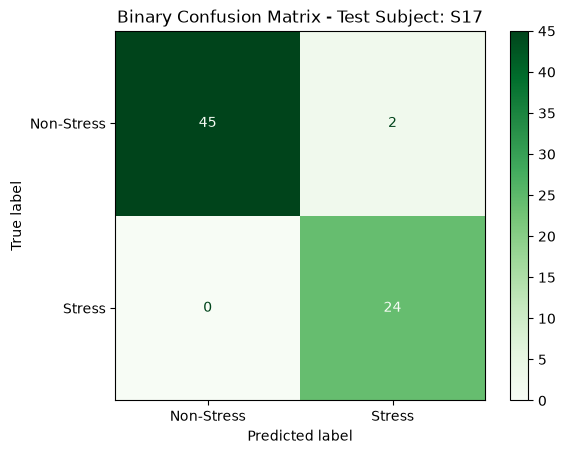

In [23]:
cm_bin = confusion_matrix(y_test, preds, labels=[0,1])
disp_bin = ConfusionMatrixDisplay(cm_bin, display_labels=['Non-Stress','Stress'])
disp_bin.plot(cmap='Greens')
plt.title(f"Binary Confusion Matrix - Test Subject: {test_subj}")
plt.savefig('models/binary_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [24]:
import json
with open('models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)